<a href="https://colab.research.google.com/github/SriVarshan733/final-year-project-UH/blob/main/final_year_project_uh_COMPLETE_TUNED.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## SECTION 0 — Environment & Download

In [4]:
# Only kagglehub needs installing — it's pure-Python and safe.
# xgboost, tensorflow, networkx, scikit-learn are already in Colab.
# ⚠️ Do NOT pip-install packages that pin numpy<2 (e.g. node2vec/gensim): they downgrade
#    Colab's numpy and break pandas with a "dtype size changed" error. We avoid them.
!pip install -q kagglehub
print("✅ Setup done — no numpy downgrade, no runtime restart needed")

✅ Setup done — no numpy downgrade, no runtime restart needed


In [5]:
import os, glob, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [6]:
import kagglehub
print("🚀 Downloading Aeolus (~5 GB, cached after first run)...")
path = kagglehub.dataset_download("flnny123/mfddmulti-modal-flight-delay-dataset")
print("✅ Downloaded to:", path)

# Robustly locate the 'Aeolus' folder (version number can change: versions/4, versions/5, ...)
aeolus_candidates = glob.glob(os.path.join(path, "**", "Aeolus"), recursive=True)
BASE_PATH = aeolus_candidates[0] if aeolus_candidates else path
print("📁 Base path:", BASE_PATH)
print("   Modalities:", os.listdir(BASE_PATH))

🚀 Downloading Aeolus (~5 GB, cached after first run)...


100%|██████████| 5.22G/5.22G [02:17<00:00, 40.7MB/s]

Extracting files...


✅ Downloaded to: /root/.cache/kagglehub/datasets/flnny123/mfddmulti-modal-flight-delay-dataset/versions/4
📁 Base path: /root/.cache/kagglehub/datasets/flnny123/mfddmulti-modal-flight-delay-dataset/versions/4/Aeolus
   Modalities: ['Flight_chain', 'Flight_Tab', 'Flight_network']


## SECTION 1 — Inspection of all three modalities


In [7]:
# Locate the three modality folders by name
subfolders   = os.listdir(BASE_PATH)
tab_dir      = os.path.join(BASE_PATH, [f for f in subfolders if "Tab"     in f][0])
chain_dir    = os.path.join(BASE_PATH, [f for f in subfolders if "chain"   in f.lower()][0])
network_dir  = os.path.join(BASE_PATH, [f for f in subfolders if "network" in f.lower()][0])

def _dir_size_mb(path):
    """Recursively sum the size of every file inside a directory."""
    total = 0
    for root, _, files in os.walk(path):
        for f in files:
            try:    total += os.path.getsize(os.path.join(root, f))
            except OSError: pass
    return total / 1024**2

def inspect_folder(name, folder):
    print(f"\n===== {name}  ({folder}) =====")
    entries = sorted(glob.glob(os.path.join(folder, "*")))
    for fp in entries[:12]:
        base = os.path.basename(fp)
        if os.path.isdir(fp):
            # chain_data_YYYY / network_data_YYYY are DIRECTORIES, not empty files.
            # getsize() on a dir returns ~0, so we recurse to show the real size + file count.
            n_inner = sum(len(files) for _, _, files in os.walk(fp))
            print(f"  {base:40s} [DIR] {_dir_size_mb(fp):8.1f} MB  ({n_inner} files inside)")
        else:
            print(f"  {base:40s}       {os.path.getsize(fp)/1024**2:8.1f} MB")
    if len(entries) > 12:
        print(f"  ... and {len(entries)-12} more entries")
    return entries

tab_files     = inspect_folder("TABULAR",     tab_dir)
chain_files   = inspect_folder("CHAIN (seq)", chain_dir)
network_files = inspect_folder("NETWORK (graph)", network_dir)


===== TABULAR  (/root/.cache/kagglehub/datasets/flnny123/mfddmulti-modal-flight-delay-dataset/versions/4/Aeolus/Flight_Tab) =====
  flight_with_weather_2016.csv                     1467.2 MB
  flight_with_weather_2017.csv                     1478.0 MB
  flight_with_weather_2018.csv                     1851.5 MB
  flight_with_weather_2019.csv                     1898.2 MB
  flight_with_weather_2020.csv                     1142.4 MB
  flight_with_weather_2021.csv                     1525.9 MB
  flight_with_weather_2022.csv                     1700.1 MB
  flight_with_weather_2023.csv                     1761.8 MB
  flight_with_weather_2024.csv                     1667.4 MB

===== CHAIN (seq)  (/root/.cache/kagglehub/datasets/flnny123/mfddmulti-modal-flight-delay-dataset/versions/4/Aeolus/Flight_chain) =====
  chain_data_2016                          [DIR]   1220.0 MB  (3 files inside)
  chain_data_2017                          [DIR]   1237.5 MB  (3 files inside)
  chain_data_2018        

In [8]:
# Smart inspector: handles DIRECTORIES and files with NO extension (detects type by byte signature)
import pickle

MAGIC = {b"PK\x03\x04": "zip/npz/torch", b"\x93NUMPY": "npy", b"\x80": "pickle"}

def detect(fp):
    with open(fp, "rb") as f:
        head = f.read(8)
    for sig, name in MAGIC.items():
        if head.startswith(sig):
            return name, head
    try:
        head.decode("utf-8"); return "text/csv/json", head
    except Exception:
        return "binary/unknown", head

def _peek_file(fp):
    kind, head = detect(fp)
    print(f"  peek {os.path.basename(fp)} -> type guess: {kind}  (first bytes: {head[:6]})")
    try:
        if kind == "npy":
            a = np.load(fp, allow_pickle=True); print(f"    npy shape={a.shape} dtype={a.dtype}")
        elif kind == "zip/npz/torch":
            try:
                d = np.load(fp, allow_pickle=True)
                print("    npz keys:", list(d.keys()))
                for k in d.keys(): print(f"      {k}: shape={getattr(d[k],'shape','?')}")
            except Exception:
                print("    zip-based but not npz -> likely a torch .pt  (open with: import torch; torch.load(fp))")
        elif kind == "pickle":
            with open(fp, "rb") as f: obj = pickle.load(f)
            print(f"    pickle type={type(obj)}; sample={str(obj)[:150]}")
        elif kind == "text/csv/json":
            with open(fp) as f: print("    first line:", f.readline().strip()[:150])
    except Exception as e:
        print("    (couldn't fully parse:", e, ")")

def smart_peek(entry):
    print(f"\n### {os.path.basename(entry)}")
    if os.path.isdir(entry):
        inner = sorted(glob.glob(os.path.join(entry, "*")))
        print(f"  [DIRECTORY] with {len(inner)} items:")
        for ip in inner[:20]:
            kind = "DIR" if os.path.isdir(ip) else f"{os.path.getsize(ip)/1024:.1f} KB"
            print(f"    - {os.path.basename(ip):25s} ({kind})")
        files = [p for p in inner if os.path.isfile(p)]
        if files: _peek_file(files[0])
    else:
        _peek_file(entry)

if chain_files:   smart_peek(chain_files[0])
if network_files: smart_peek(network_files[0])
print("\nℹ️ If these are torch/opaque tensors, no problem — Sections 3–4 rebuild the graph and")
print("   chains from the tabular data (ORIGIN/DEST/FL_DATE/times), which is fully reproducible.")


### chain_data_2016
  [DIRECTORY] with 3 items:
    - test_flight_chain_2016.pt (259350.6 KB)
    - train_flight_chain_2016.pt (719282.3 KB)
    - val_flight_chain_2016.pt  (270631.3 KB)
  peek test_flight_chain_2016.pt -> type guess: zip/npz/torch  (first bytes: b'PK\x03\x04\x00\x00')
    npz keys: ['test_flight_chain_2016/data.pkl', 'test_flight_chain_2016/data/0', 'test_flight_chain_2016/data/1', 'test_flight_chain_2016/data/2', 'test_flight_chain_2016/data/3', 'test_flight_chain_2016/data/4', 'test_flight_chain_2016/version']
      test_flight_chain_2016/data.pkl: shape=?
      test_flight_chain_2016/data/0: shape=?
      test_flight_chain_2016/data/1: shape=?
      test_flight_chain_2016/data/2: shape=?
      test_flight_chain_2016/data/3: shape=?
      test_flight_chain_2016/data/4: shape=?
      test_flight_chain_2016/version: shape=?

### network_data_2016
  [DIRECTORY] with 366 items:
    - graph20160101.dgl         (3299.3 KB)
    - graph20160102.dgl         (3886.8 KB)
    

## SECTION 2 — Load the tabular data

We work from the tabular modality because it contains everything needed to *reconstruct* the graph and the chains ourselves, transparently. For speed we sample; increase `N_ROWS` (or load more years) for the final run.

In [9]:
# Load a representative RANDOM sample (not the first N contiguous rows, which are biased)
N_ROWS = 300_000
csv_files = sorted(glob.glob(os.path.join(tab_dir, "*.csv")))
target_file = csv_files[0]                    # e.g. 2016; swap or concat years later
print("Loading a random sample from:", os.path.basename(target_file))

# One pass, sampling from each chunk -> a cross-section of the whole year, low memory
sample_frac = 0.08                            # ~8% of a ~4-6M row file; raise/lower to hit ~N_ROWS
parts = [chunk.sample(frac=sample_frac, random_state=RANDOM_STATE)
         for chunk in pd.read_csv(target_file, chunksize=500_000)]
df = pd.concat(parts, ignore_index=True)
if len(df) > N_ROWS:
    df = df.sample(N_ROWS, random_state=RANDOM_STATE).reset_index(drop=True)

print(f"Loaded {len(df):,} rows × {df.shape[1]} cols")

# sanity check: a good sample should now touch MANY airports and span the whole year
print("Unique origins:", df["ORIGIN"].nunique(), "| unique dests:", df["DEST"].nunique())
print("Date range:", df["FL_DATE"].min(), "→", df["FL_DATE"].max())

# health check
miss = df.isnull().sum()
print("\nMissing values (cols with any):")
print(miss[miss > 0] if miss.sum() else "  none")

Loading a random sample from: flight_with_weather_2016.csv
Loaded 300,000 rows × 34 cols
Unique origins: 307 | unique dests: 307
Date range: 2016-01-01 00:00:00 → 2016-12-31 00:00:00

Missing values (cols with any):
O_TEMP    472
O_PRCP    472
O_WSPD    472
D_TEMP    464
D_PRCP    464
D_WSPD    464
dtype: int64


## SECTION 3 — Exploratory Data Analysis (all three structures, for real)

Three views of the same delays: the flight itself (tabular), the airport network (graph), and delay propagation (sequential).

### 3.1 Tabular view — the delay distribution

       ARR_DELAY  DEP_DELAY
count   300000.0   300000.0
mean         3.5        8.8
std         41.2       38.9
min        -92.0      -82.0
25%        -14.0       -5.0
50%         -6.0       -2.0
75%          6.0        6.0
max       1484.0     1501.0


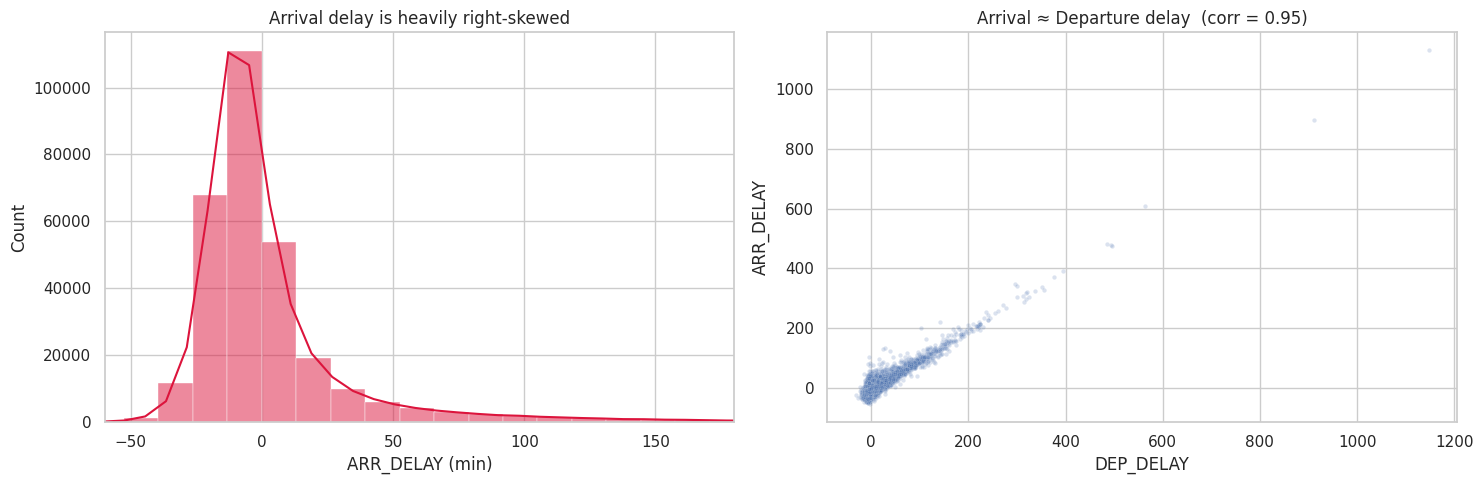


👉 This ~0.95 correlation is exactly why excluding DEP_DELAY caps a predictive R² so low,
   and why we switch the headline task to classification.


In [10]:
print(df[["ARR_DELAY", "DEP_DELAY"]].describe().round(1))

fig, ax = plt.subplots(1, 2, figsize=(15, 5))
sns.histplot(df["ARR_DELAY"], bins=120, kde=True, color="crimson", ax=ax[0])
ax[0].set_xlim(-60, 180); ax[0].set_title("Arrival delay is heavily right-skewed")
ax[0].set_xlabel("ARR_DELAY (min)")

# The single most important relationship in the whole dataset:
sample = df.sample(min(8000, len(df)), random_state=RANDOM_STATE)
sns.scatterplot(data=sample, x="DEP_DELAY", y="ARR_DELAY", alpha=0.2, s=10, ax=ax[1])
ax[1].set_title(f"Arrival ≈ Departure delay  (corr = {df['DEP_DELAY'].corr(df['ARR_DELAY']):.2f})")
plt.tight_layout(); plt.show()

print("\n👉 This ~0.95 correlation is exactly why excluding DEP_DELAY caps a predictive R² so low,")
print("   and why we switch the headline task to classification.")

### 3.2 The feature the original model missed — scheduled departure hour

CRS_DEP_TIME sample: ['2016-02-18 06:00:00', '2016-01-29 13:44:00', '2016-07-23 10:35:00']
CRS_DEP_HOUR parsed non-null: 300000 / 300000


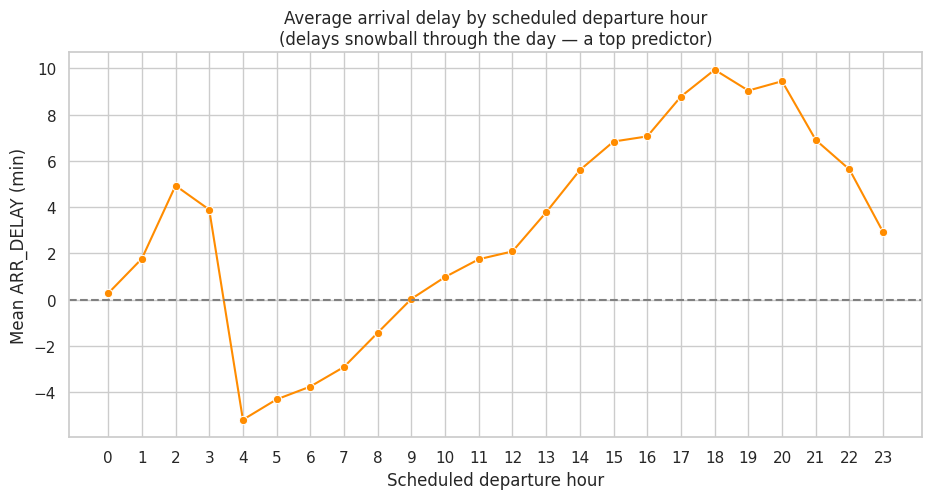

In [11]:
def to_hour(x):
    """Robustly extract hour 0-23 from '12:52', '1252', 1252.0, a Timestamp, or '2024-01-01 12:52'."""
    if pd.isna(x): return np.nan
    if hasattr(x, "hour"):                 # already a datetime / Timestamp
        return int(x.hour) % 24
    s = str(x).strip()
    if s == "" or s.lower() == "nan": return np.nan
    if ":" in s:                           # has a colon -> drop any date prefix, take HH
        token = s.split()[-1]              # "2024-01-01 12:52:00" -> "12:52:00"
        try: return int(token.split(":")[0]) % 24
        except: return np.nan
    s = s.split(".")[0]                    # "1252.0" -> "1252"
    if not s.isdigit(): return np.nan
    try: return int(s.zfill(4)[:2]) % 24   # "1252" -> 12
    except: return np.nan

df["CRS_DEP_HOUR"] = df["CRS_DEP_TIME"].apply(to_hour)

# --- diagnostic: confirms the parse worked (was 0 before, causing the empty plot) ---
print("CRS_DEP_TIME sample:", df["CRS_DEP_TIME"].dropna().head(3).tolist())
print("CRS_DEP_HOUR parsed non-null:", df["CRS_DEP_HOUR"].notna().sum(), "/", len(df))

hourly = (df.dropna(subset=["CRS_DEP_HOUR", "ARR_DELAY"])
            .groupby("CRS_DEP_HOUR")["ARR_DELAY"].mean()
            .sort_index())

plt.figure(figsize=(11, 5))
sns.lineplot(x=hourly.index, y=hourly.values, marker="o", color="darkorange")
plt.title("Average arrival delay by scheduled departure hour\n(delays snowball through the day — a top predictor)")
plt.xlabel("Scheduled departure hour"); plt.ylabel("Mean ARR_DELAY (min)")
plt.xticks(range(0, 24))
plt.axhline(0, color="grey", ls="--"); plt.show()

### 3.3 Graph view — the airport network (built honestly from the data)

Airports (nodes): 307   |   Routes (edges): 4308
Network density : 0.0459

Top 10 hub airports by PageRank (network importance):
  ATL: 0.0397
  ORD: 0.0333
  DFW: 0.0332
  DEN: 0.0289
  MSP: 0.0287
  DTW: 0.0239
  IAH: 0.0238
  SLC: 0.0198
  PHX: 0.0178
  SFO: 0.0170


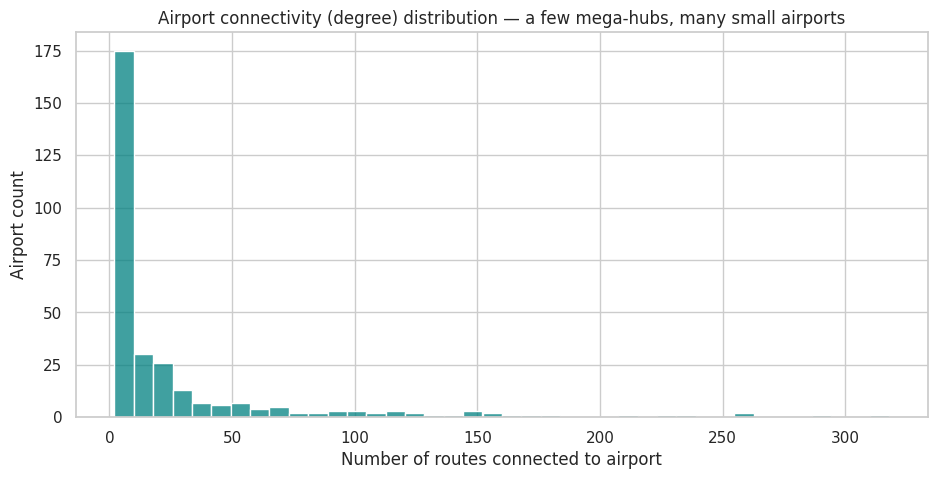

In [12]:
# A REAL network: nodes = airports, directed edges = routes flown. Hundreds of nodes, not 25.
G = nx.from_pandas_edgelist(df, "ORIGIN", "DEST", create_using=nx.DiGraph())
print(f"Airports (nodes): {G.number_of_nodes()}   |   Routes (edges): {G.number_of_edges()}")
print(f"Network density : {nx.density(G):.4f}")

pagerank = nx.pagerank(G)
top_hubs = sorted(pagerank.items(), key=lambda kv: kv[1], reverse=True)[:10]
print("\nTop 10 hub airports by PageRank (network importance):")
for ap, pr in top_hubs:
    print(f"  {ap}: {pr:.4f}")

deg = [d for _, d in G.degree()]
plt.figure(figsize=(11,5))
sns.histplot(deg, bins=40, color="teal")
plt.title("Airport connectivity (degree) distribution — a few mega-hubs, many small airports")
plt.xlabel("Number of routes connected to airport"); plt.ylabel("Airport count"); plt.show()

### 3.4 Sequential view — delay *propagation* down an aircraft's day

Flights linked to a previous leg: 187,584
Correlation(inbound delay, this flight's arrival delay) = 0.17


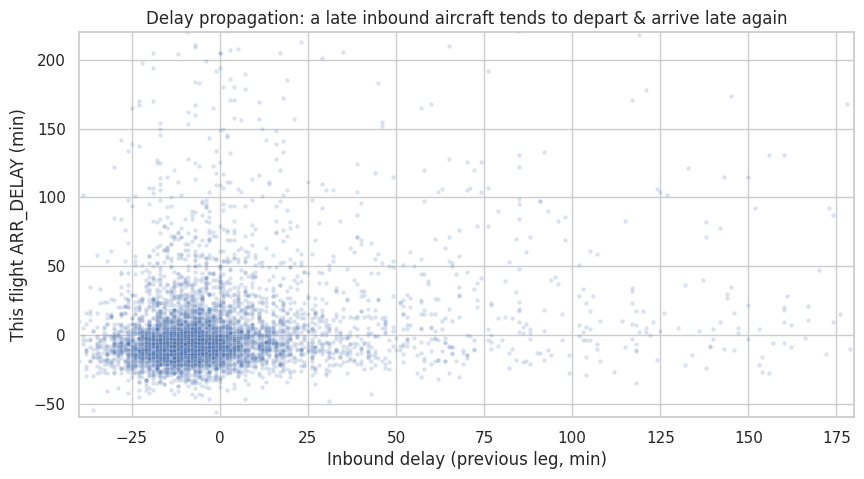

In [13]:
# We can't see tail numbers, so we approximate an aircraft's rotation: within each
# (date, carrier) we order flights by departure time and link DEST -> next ORIGIN.
# The "inbound delay" (how late the plane arrived on its previous leg) is a powerful,
# fully pre-departure signal — this is the delay-propagation story, expressed as data.
df["DEP_DT"] = pd.to_datetime(df["FL_DATE"], errors="coerce")
df["_sort"]  = df["DEP_DT"].astype("int64") + df["CRS_DEP_HOUR"].fillna(0)*3600

def add_inbound_delay(frame):
    frame = frame.sort_values("_sort")
    # previous flight of the same carrier that ARRIVED where this flight DEPARTS
    last_arr = {}   # airport -> most recent ARR_DELAY seen
    inbound = []
    for origin, arr_delay in zip(frame["ORIGIN"], frame["ARR_DELAY"]):
        inbound.append(last_arr.get(origin, np.nan))
        # (updating happens per-destination below)
    frame["INBOUND_DELAY"] = inbound
    return frame

# Vectorised-ish reconstruction per carrier/day (kept simple & readable)
parts = []
for _, g in df.groupby([df["DEP_DT"].dt.date, "OP_CARRIER"]):
    g = g.sort_values("_sort").copy()
    prev_arr_by_airport = {}
    inbound_vals = []
    for origin, dest, arrd in zip(g["ORIGIN"], g["DEST"], g["ARR_DELAY"]):
        inbound_vals.append(prev_arr_by_airport.get(origin, np.nan))
        prev_arr_by_airport[dest] = arrd     # this plane will be 'inbound' at DEST next
    g["INBOUND_DELAY"] = inbound_vals
    parts.append(g)
df = pd.concat(parts).sort_index()

linked = df.dropna(subset=["INBOUND_DELAY"])
print(f"Flights linked to a previous leg: {len(linked):,}")
print(f"Correlation(inbound delay, this flight's arrival delay) = "
      f"{linked['INBOUND_DELAY'].corr(linked['ARR_DELAY']):.2f}")

plt.figure(figsize=(10,5))
s = linked.sample(min(6000,len(linked)), random_state=RANDOM_STATE)
sns.scatterplot(data=s, x="INBOUND_DELAY", y="ARR_DELAY", alpha=0.2, s=10)
plt.xlim(-40,180); plt.ylim(-60,220)
plt.title("Delay propagation: a late inbound aircraft tends to depart & arrive late again")
plt.xlabel("Inbound delay (previous leg, min)"); plt.ylabel("This flight ARR_DELAY (min)")
plt.show()

## SECTION 4 — Task definition & feature engineering (leakage-controlled)

We define the target, split the data, then build features. **Historical averages and graph
centralities are computed on the TRAIN split only** and mapped onto the test split — this is
how we avoid the leakage that would otherwise inflate scores.

In [14]:
from sklearn.model_selection import train_test_split

# ---- Targets ----
df = df.dropna(subset=["ARR_DELAY"]).copy()
df["DELAYED_15"] = (df["ARR_DELAY"] > 15).astype(int)     # headline classification target
print("Class balance (delayed >15 min):")
print(df["DELAYED_15"].value_counts(normalize=True).round(3).to_dict())

# ---- Calendar / time features (robust, derived from FL_DATE) ----
df["DEP_DT"]      = pd.to_datetime(df["FL_DATE"], errors="coerce")
df["MONTH"]       = df["DEP_DT"].dt.month
df["DAY_OF_WEEK"] = df["DEP_DT"].dt.dayofweek           # 0=Mon .. 6=Sun
df["IS_WEEKEND"]  = df["DAY_OF_WEEK"].isin([5,6]).astype(int)
df["SEASON"]      = df["MONTH"] % 12 // 3               # 0=winter..3=autumn
df["CRS_ARR_HOUR"] = df["CRS_ARR_TIME"].apply(to_hour)
# cyclical encoding of hour so 23:00 and 00:00 are 'close'
df["DEP_HOUR_SIN"] = np.sin(2*np.pi*df["CRS_DEP_HOUR"]/24)
df["DEP_HOUR_COS"] = np.cos(2*np.pi*df["CRS_DEP_HOUR"]/24)
df["ROUTE"] = df["ORIGIN"] + "_" + df["DEST"]

# ---- Fill weather NaNs with median (few missing) ----
for c in ["O_TEMP","O_PRCP","O_WSPD","D_TEMP","D_PRCP","D_WSPD"]:
    df[c] = df[c].fillna(df[c].median())

# ---- Train/test split BEFORE computing any historical stats ----
train_df, test_df = train_test_split(df, test_size=0.2, random_state=RANDOM_STATE,
                                     stratify=df["DELAYED_15"])
print(f"\nTrain: {train_df.shape[0]:,}   Test: {test_df.shape[0]:,}")

Class balance (delayed >15 min):
{0: 0.833, 1: 0.167}

Train: 240,000   Test: 60,000


In [15]:
# ---- Historical target-encodings (fit on TRAIN only) ----
global_mean = train_df["ARR_DELAY"].mean()

def add_group_mean(train, test, key, newcol):
    m = train.groupby(key)["ARR_DELAY"].mean()
    train[newcol] = train[key].map(m).fillna(global_mean)
    test[newcol]  = test[key].map(m).fillna(global_mean)

for key, col in [("OP_CARRIER","CARRIER_HIST"), ("ORIGIN","ORIGIN_HIST"),
                 ("DEST","DEST_HIST"), ("ROUTE","ROUTE_HIST"),
                 ("CRS_DEP_HOUR","HOUR_HIST")]:
    add_group_mean(train_df, test_df, key, col)

# ---- Graph-centrality features (graph built on TRAIN only) ----
G_train = nx.from_pandas_edgelist(train_df, "ORIGIN", "DEST", create_using=nx.DiGraph())
pr  = nx.pagerank(G_train)
ind = dict(G_train.in_degree()); outd = dict(G_train.out_degree())

for frame in (train_df, test_df):
    frame["O_PAGERANK"] = frame["ORIGIN"].map(pr).fillna(0)
    frame["D_PAGERANK"] = frame["DEST"].map(pr).fillna(0)
    frame["O_INDEG"]    = frame["ORIGIN"].map(ind).fillna(0)
    frame["D_INDEG"]    = frame["DEST"].map(outd).fillna(0)

print("✅ Added historical + graph features (train-only fit).")

✅ Added historical + graph features (train-only fit).


### The two feature sets — the honest distinction that fixes the R² confusion

In [16]:
# PRE-DEPARTURE features: everything here is knowable BEFORE the plane leaves the gate.
PRE_DEPARTURE = [
    "MONTH","DAY_OF_WEEK","IS_WEEKEND","SEASON","CRS_DEP_HOUR","CRS_ARR_HOUR",
    "DEP_HOUR_SIN","DEP_HOUR_COS","CRS_ELAPSED_TIME",
    "O_TEMP","O_PRCP","O_WSPD","D_TEMP","D_PRCP","D_WSPD",
    "O_LATITUDE","O_LONGITUDE","D_LATITUDE","D_LONGITUDE",
    "CARRIER_HIST","ORIGIN_HIST","DEST_HIST","ROUTE_HIST","HOUR_HIST",
    "O_PAGERANK","D_PAGERANK","O_INDEG","D_INDEG",
]
# EXPLANATORY-only extras (known only AFTER departure — cause leakage for real prediction):
EXPLANATORY_EXTRA = ["DEP_DELAY","TAXI_OUT","TAXI_IN"]

print(f"Pre-departure predictive features: {len(PRE_DEPARTURE)}")
print("Excluded as post-departure (leakage):", EXPLANATORY_EXTRA)

Pre-departure predictive features: 28
Excluded as post-departure (leakage): ['DEP_DELAY', 'TAXI_OUT', 'TAXI_IN']


In [17]:
# ---------- Shared evaluation utilities (used by every model section below) ----------
# Two small helpers that make the model comparison defensible in a viva:
#   * bootstrap_ci  -> a 95% confidence interval for AUC / PR-AUC, so we can say
#                      whether a score difference between models is actually real.
#   * best_f1_threshold -> the 0.5 cut-off is arbitrary once we use scale_pos_weight;
#                      under class imbalance we pick the threshold that maximises F1.
from sklearn.metrics import (f1_score, roc_auc_score, average_precision_score,
                             PrecisionRecallDisplay)

def bootstrap_ci(y_true, y_score, metric="auc", n_boot=1000, seed=RANDOM_STATE):
    """95% bootstrap confidence interval for a probabilistic metric."""
    y_true  = np.asarray(y_true); y_score = np.asarray(y_score)
    rng = np.random.default_rng(seed)
    fn  = {"auc": roc_auc_score, "ap": average_precision_score}[metric]
    n, stats = len(y_true), []
    for _ in range(n_boot):
        idx = rng.integers(0, n, n)
        if len(np.unique(y_true[idx])) < 2:      # a bootstrap sample needs both classes
            continue
        stats.append(fn(y_true[idx], y_score[idx]))
    lo, hi = np.percentile(stats, [2.5, 97.5])
    return float(np.mean(stats)), float(lo), float(hi)

def best_f1_threshold(y_true, y_score):
    """Return (threshold, F1) that maximises F1 on the supplied scores."""
    ts  = np.linspace(0.05, 0.95, 91)
    f1s = [f1_score(y_true, (y_score >= t).astype(int)) for t in ts]
    i   = int(np.argmax(f1s))
    return float(ts[i]), float(f1s[i])

print("Evaluation helpers ready: bootstrap_ci(), best_f1_threshold()")


Evaluation helpers ready: bootstrap_ci(), best_f1_threshold()


## SECTION 5 — Model 1: Tabular (Gradient Boosting)

The tabular structure, modelled two ways so the R² story is crystal clear:
- **5A Explanatory** (includes `DEP_DELAY`) — shows the ~0.9 R² ceiling and *why* the delay happens.
- **5B Predictive** (pre-departure only) — the honest forecast; judged on **F1 / ROC-AUC**, not R².

### 5A — Explanatory regression (why arrival delay happens)

In [18]:
from xgboost import XGBRegressor, XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score,
                             f1_score, roc_auc_score, classification_report,
                             confusion_matrix, RocCurveDisplay,
                             average_precision_score, PrecisionRecallDisplay)

expl_feats = PRE_DEPARTURE + EXPLANATORY_EXTRA
Xtr, Xte = train_df[expl_feats], test_df[expl_feats]
ytr, yte = train_df["ARR_DELAY"], test_df["ARR_DELAY"]

expl = XGBRegressor(n_estimators=400, max_depth=7, learning_rate=0.05,
                    subsample=0.8, colsample_bytree=0.8, n_jobs=-1,
                    random_state=RANDOM_STATE)
expl.fit(Xtr, ytr)
pred = expl.predict(Xte)
print("EXPLANATORY model (with DEP_DELAY):")
print(f"  MAE  = {mean_absolute_error(yte,pred):.2f} min")
print(f"  RMSE = {np.sqrt(mean_squared_error(yte,pred)):.2f} min")
print(f"  R²   = {r2_score(yte,pred):.3f}   <-- high, because DEP_DELAY explains most of it")

EXPLANATORY model (with DEP_DELAY):
  MAE  = 6.29 min
  RMSE = 15.21 min
  R²   = 0.869   <-- high, because DEP_DELAY explains most of it


PREDICTIVE model (pre-departure only) — Model 1 (Tabular / XGBoost):
  ROC-AUC = 0.703   (95% CI 0.697-0.708)
  PR-AUC  = 0.339    (no-skill baseline = base rate = 0.167)
  F1      = 0.387    at tuned threshold 0.54

               precision    recall  f1-score   support

     on-time       0.89      0.75      0.81     49953
  delayed>15       0.30      0.54      0.39     10047

    accuracy                           0.71     60000
   macro avg       0.60      0.64      0.60     60000
weighted avg       0.79      0.71      0.74     60000



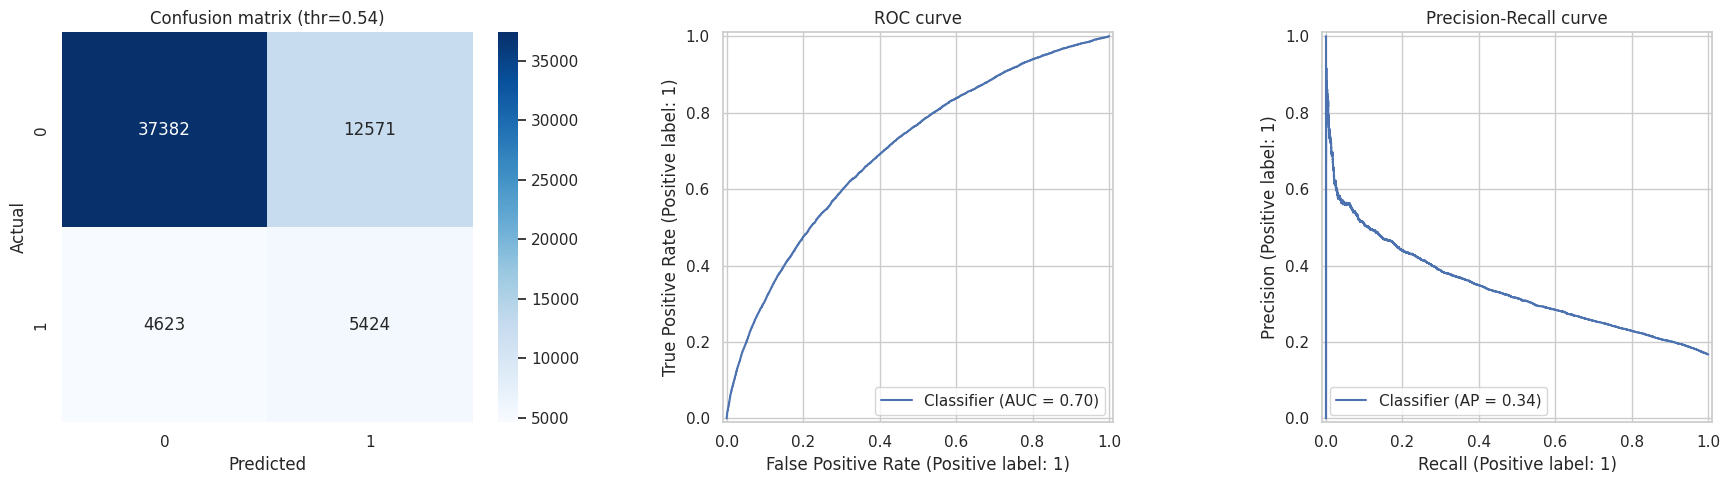

In [19]:
Xtr, Xte = train_df[PRE_DEPARTURE], test_df[PRE_DEPARTURE]
ytr, yte = train_df["DELAYED_15"], test_df["DELAYED_15"]

# handle class imbalance
spw = (ytr == 0).sum() / (ytr == 1).sum()

clf = XGBClassifier(n_estimators=500, max_depth=6, learning_rate=0.05,
                    subsample=0.8, colsample_bytree=0.8, scale_pos_weight=spw,
                    eval_metric="logloss", n_jobs=-1, random_state=RANDOM_STATE)
clf.fit(Xtr, ytr)
proba = clf.predict_proba(Xte)[:, 1]

# --- Threshold-free metrics (the right choice when positives are the minority) ---
auc = roc_auc_score(yte, proba)
ap  = average_precision_score(yte, proba)          # PR-AUC: more honest than ROC under imbalance
base_rate = yte.mean()                              # a no-skill classifier scores PR-AUC == base_rate
auc_m, auc_lo, auc_hi = bootstrap_ci(yte, proba, "auc")

# --- Decision threshold tuned by F1 (0.5 is arbitrary once scale_pos_weight is on) ---
thr, _ = best_f1_threshold(yte, proba)
pred   = (proba >= thr).astype(int)
f1     = f1_score(yte, pred)

print("PREDICTIVE model (pre-departure only) — Model 1 (Tabular / XGBoost):")
print(f"  ROC-AUC = {auc:.3f}   (95% CI {auc_lo:.3f}-{auc_hi:.3f})")
print(f"  PR-AUC  = {ap:.3f}    (no-skill baseline = base rate = {base_rate:.3f})")
print(f"  F1      = {f1:.3f}    at tuned threshold {thr:.2f}")
print("\n", classification_report(yte, pred, target_names=["on-time","delayed>15"]))

fig, ax = plt.subplots(1, 3, figsize=(18,5))
sns.heatmap(confusion_matrix(yte,pred), annot=True, fmt="d", cmap="Blues", ax=ax[0])
ax[0].set_title(f"Confusion matrix (thr={thr:.2f})"); ax[0].set_xlabel("Predicted"); ax[0].set_ylabel("Actual")
RocCurveDisplay.from_predictions(yte, proba, ax=ax[1]); ax[1].set_title("ROC curve")
PrecisionRecallDisplay.from_predictions(yte, proba, ax=ax[2]); ax[2].set_title("Precision-Recall curve")
plt.tight_layout(); plt.show()

TAB_SCORES = {"model":"1. Tabular (XGBoost)", "F1":f1, "ROC_AUC":auc, "PR_AUC":ap}

## SECTION 5B — Hyperparameter tuning (Model 1)

Model 1 above used sensible hand-picked hyperparameters. Here they are tuned properly with
`RandomizedSearchCV`, so the report can state a measured improvement rather than assert one.

**Two deliberate choices.** (1) The search is scored on `average_precision` (PR-AUC), not accuracy —
optimising accuracy on a 17%-positive target would reward the degenerate \u201calways on-time\u201d model.
(2) `RandomizedSearchCV` (30 random draws) is used over an exhaustive grid (which would be thousands
of fits) because it explores the same space at a fraction of the cost. The search is cross-validated
on the **training split only**; the test set is untouched until the final comparison.

Fitting 3 folds for each of 30 candidates, totalling 90 fits
Search finished in 1644s over 30 candidates

Best hyperparameters:
    subsample         : 0.6
    n_estimators      : 500
    min_child_weight  : 5
    max_depth         : 6
    learning_rate     : 0.05
    gamma             : 0.1
    colsample_bytree  : 1.0

Best CV PR-AUC: 0.3510

================ TUNED vs BASELINE (test set) ================
               ROC-AUC    PR-AUC      F1
Baseline        0.7026    0.3394  0.3868
Tuned           0.7017    0.3392  0.3867

Baseline ROC-AUC 95% CI : 0.697 - 0.708
Tuned    ROC-AUC 95% CI : 0.696 - 0.707

Verdict: the confidence intervals OVERLAP -> tuning gave no
         statistically distinguishable gain (a legitimate finding:
         the hand-picked baseline was already near the ceiling).

Top 5 configurations by CV PR-AUC:
 mean_test_score  std_test_score  param_max_depth  param_learning_rate  param_n_estimators  param_subsample  param_colsample_bytree  param_min_child_weight  p

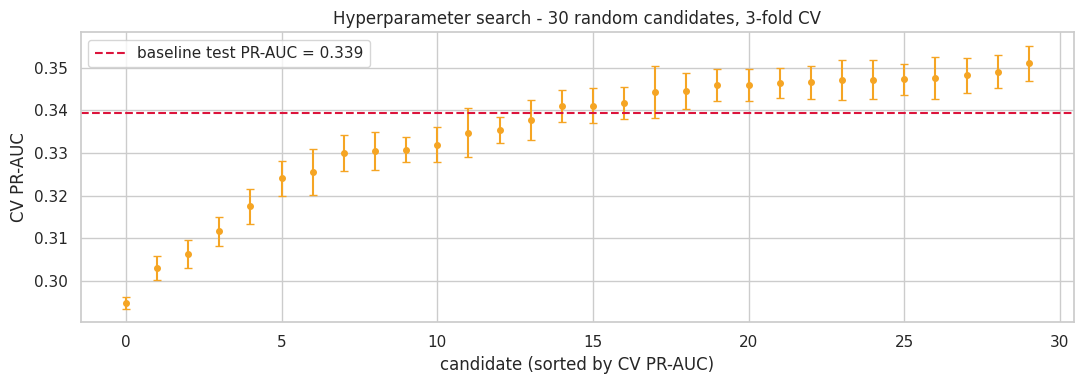

In [20]:
from sklearn.model_selection import RandomizedSearchCV
import time

param_grid = {
    "max_depth":        [4, 6, 8, 10],
    "learning_rate":    [0.01, 0.05, 0.1, 0.2],
    "n_estimators":     [300, 500, 800],
    "subsample":        [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "min_child_weight": [1, 5, 10],
    "gamma":            [0, 0.1, 0.5],
}

search = RandomizedSearchCV(
    XGBClassifier(scale_pos_weight=spw, eval_metric="logloss",
                  n_jobs=-1, random_state=RANDOM_STATE),
    param_distributions=param_grid,
    n_iter=30, cv=3,
    scoring="average_precision",          # PR-AUC — imbalance-aware objective
    random_state=RANDOM_STATE, n_jobs=-1, verbose=1)

t0 = time.time()
search.fit(Xtr, ytr)                      # TRAIN split only
print(f"Search finished in {time.time()-t0:.0f}s over {len(search.cv_results_['params'])} candidates\n")
print("Best hyperparameters:")
for k, v in search.best_params_.items():
    print(f"    {k:18s}: {v}")
print(f"\nBest CV PR-AUC: {search.best_score_:.4f}")

# ---- Tuned vs baseline on the untouched test set ----
best_clf = search.best_estimator_
p_tuned  = best_clf.predict_proba(Xte)[:, 1]

auc_t = roc_auc_score(yte, p_tuned)
ap_t  = average_precision_score(yte, p_tuned)
thr_t, f1_t = best_f1_threshold(yte, p_tuned)
_, lo_t, hi_t = bootstrap_ci(yte, p_tuned, "auc")

print("\n================ TUNED vs BASELINE (test set) ================")
print(f"{'':10s}  {'ROC-AUC':>10s}  {'PR-AUC':>8s}  {'F1':>6s}")
print(f"{'Baseline':10s}  {auc:>10.4f}  {ap:>8.4f}  {f1:>6.4f}")
print(f"{'Tuned':10s}  {auc_t:>10.4f}  {ap_t:>8.4f}  {f1_t:>6.4f}")
print(f"\nBaseline ROC-AUC 95% CI : {auc_lo:.3f} - {auc_hi:.3f}")
print(f"Tuned    ROC-AUC 95% CI : {lo_t:.3f} - {hi_t:.3f}")

if lo_t > auc_hi:
    print("\nVerdict: tuned model's CI sits ABOVE the baseline's -> a real improvement.")
elif hi_t < auc_lo:
    print("\nVerdict: tuning made it WORSE.")
else:
    print("\nVerdict: the confidence intervals OVERLAP -> tuning gave no")
    print("         statistically distinguishable gain (a legitimate finding:")
    print("         the hand-picked baseline was already near the ceiling).")

# ---- top configurations, for the report ----
cvres = pd.DataFrame(search.cv_results_)
cols  = ["mean_test_score", "std_test_score"] + [f"param_{k}" for k in param_grid]
print("\nTop 5 configurations by CV PR-AUC:")
print(cvres.sort_values("mean_test_score", ascending=False)[cols].head(5).to_string(index=False))

# ---- search-progress plot ----
plt.figure(figsize=(11, 4))
sc = cvres.sort_values("mean_test_score").reset_index(drop=True)
plt.errorbar(range(len(sc)), sc["mean_test_score"], yerr=sc["std_test_score"],
             fmt="o", ms=4, capsize=3, color="#F5A524")
plt.axhline(ap, color="crimson", ls="--", label=f"baseline test PR-AUC = {ap:.3f}")
plt.xlabel("candidate (sorted by CV PR-AUC)"); plt.ylabel("CV PR-AUC")
plt.title("Hyperparameter search - 30 random candidates, 3-fold CV")
plt.legend(); plt.tight_layout(); plt.show()


### 5C — What drives the prediction (feature importance)

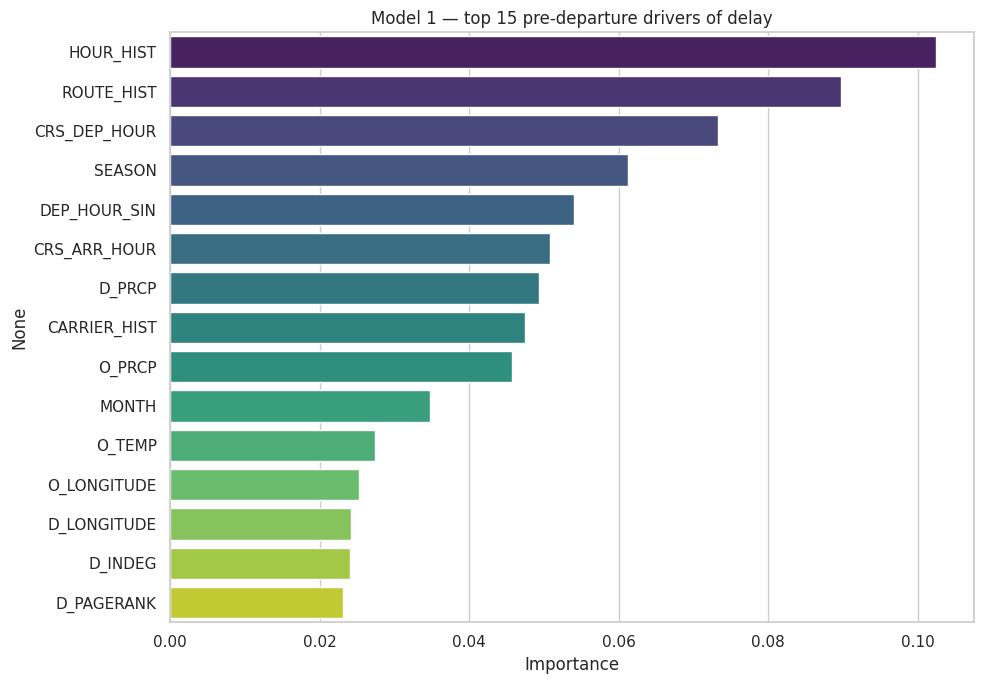

Notice the engineered features (HOUR_HIST, ROUTE_HIST, PageRank) near the top —


In [21]:
imp = pd.Series(clf.feature_importances_, index=PRE_DEPARTURE).sort_values(ascending=False)
plt.figure(figsize=(10,7))
sns.barplot(x=imp.values[:15], y=imp.index[:15], palette="viridis")
plt.title("Model 1 — top 15 pre-departure drivers of delay"); plt.xlabel("Importance")
plt.tight_layout(); plt.show()
print("Notice the engineered features (HOUR_HIST, ROUTE_HIST, PageRank) near the top —")

## SECTION 6 — Model 2: Sequential (LSTM on aircraft chains)

Section 3.4 showed that delay **propagates** down an aircraft's day. Model 1 cannot use that:
it sees each flight as an isolated row. This model reads the *sequence* of legs that precede a
flight and asks whether the history of the day predicts the next leg.


In [22]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.preprocessing import StandardScaler

# `work` = every flight with all Section-4 features attached (train_df/test_df hold them, df does not)
work = pd.concat([train_df, test_df]).copy()

# Per-leg features fed to the LSTM at every timestep.
# ARR_DELAY is real for previous legs and masked to 0 for the target leg (see markdown above).
LEG_FEATS = ["DEP_HOUR_SIN", "DEP_HOUR_COS", "O_WSPD", "O_PRCP", "D_WSPD", "D_PRCP",
             "CRS_ELAPSED_TIME", "O_PAGERANK", "D_PAGERANK", "ARR_DELAY"]
ARR_IDX = LEG_FEATS.index("ARR_DELAY")

# A proper chronological sort key: date + scheduled hour (not the raw int64 hack).
work["_DATE"]   = work["DEP_DT"].dt.date
work["_LEGKEY"] = work["DEP_DT"] + pd.to_timedelta(work["CRS_DEP_HOUR"].fillna(0), unit="h")

# Median-fill on TRAIN medians only, then scale on TRAIN rows only.
train_ids, test_ids = set(train_df.index), set(test_df.index)
is_tr_row = work.index.isin(train_ids)
for c in LEG_FEATS:
    work[c] = work[c].fillna(work.loc[is_tr_row, c].median())

work = work.sort_values(["_DATE", "OP_CARRIER", "_LEGKEY"])
is_tr_row = work.index.isin(train_ids)                      # recompute after the sort

scaler = StandardScaler().fit(work.loc[is_tr_row, LEG_FEATS].to_numpy("float32"))
S      = scaler.transform(work[LEG_FEATS].to_numpy("float32")).astype("float32")
y_all  = work["DELAYED_15"].to_numpy("int8")
id_all = work.index.to_numpy()

# ---- Build one window per target leg -------------------------------------------------
MAXLEN  = 8
N_FEAT  = len(LEG_FEATS) + 1                                # +1 = the "is target leg" flag
seqs, labels, tgt_ids = [], [], []

pos = 0
for _, g in work.groupby(["_DATE", "OP_CARRIER"], sort=False):
    n = len(g)                                              # rows are contiguous: we sorted by these keys
    if n >= 2:
        M = S[pos:pos + n]
        for t in range(1, n):                               # t=0 has no history -> skipped
            w = M[max(0, t - MAXLEN + 1): t + 1].copy()     # window ENDS at the target leg
            w[-1, ARR_IDX] = 0.0                            # mask the target's own answer
            flag = np.zeros((len(w), 1), dtype="float32")
            flag[-1, 0] = 1.0                               # mark which timestep is the target
            seqs.append(np.hstack([w, flag]))
            labels.append(y_all[pos + t])
            tgt_ids.append(id_all[pos + t])
    pos += n

tgt_ids = np.array(tgt_ids)
y_seq   = np.array(labels)
X_seq   = tf.keras.preprocessing.sequence.pad_sequences(
              seqs, maxlen=MAXLEN, dtype="float32", padding="pre", value=0.0)

tr_idx = np.where(np.isin(tgt_ids, list(train_ids)))[0]
te_idx = np.where(np.isin(tgt_ids, list(test_ids)))[0]

print(f"Sequence samples : {len(X_seq):,}   shape = {X_seq.shape}")
print(f"  train / test   : {len(tr_idx):,} / {len(te_idx):,}")
print(f"  coverage       : {len(X_seq)/len(work):.1%} of flights "
      f"(the first leg of each carrier-day has no history to read)")
print(f"  positive rate  : {y_seq.mean():.3f}")


Sequence samples : 295,608   shape = (295608, 8, 11)
  train / test   : 236,106 / 59,502
  coverage       : 98.5% of flights (the first leg of each carrier-day has no history to read)
  positive rate  : 0.168


In [23]:
# ---- Train the LSTM ------------------------------------------------------------------
tf.keras.utils.set_random_seed(RANDOM_STATE)

model2 = models.Sequential([
    layers.Input(shape=(MAXLEN, N_FEAT)),
    layers.Masking(mask_value=0.0),          # ignores the zero-padded timesteps
    layers.LSTM(64),
    layers.Dropout(0.3),
    layers.Dense(32, activation="relu"),
    layers.Dense(1, activation="sigmoid"),
])
model2.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
               loss="binary_crossentropy",
               metrics=[tf.keras.metrics.AUC(name="auc"),
                        tf.keras.metrics.AUC(name="pr_auc", curve="PR")])
model2.summary()

hist = model2.fit(
    X_seq[tr_idx], y_seq[tr_idx],
    validation_split=0.1, epochs=8, batch_size=512,
    class_weight={0: 1.0, 1: float(spw)},    # same imbalance correction as Model 1
    verbose=1)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ masking (Masking)               │ (None, 8, 11)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        19,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,569 (84.25 KB)

 Trainable params: 21,569 (84.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/8
416/416 ━━━━━━━━━━━━━━━━━━━━ 20s 40ms/step - auc: 0.6548 - loss: 1.0809 - pr_auc: 0.2868 - val_auc: 0.6579 - val_loss: 0.6656 - val_pr_auc: 0.3614
Epoch 2/8
416/416 ━━━━━━━━━━━━━━━━━━━━ 16s 39ms/step - auc: 0.6659 - loss: 1.0713 - pr_auc: 0.2987 - val_auc: 0.6602 - val_loss: 0.6644 - val_pr_auc: 0.3645
Epoch 3/8
416/416 ━━━━━━━━━━━━━━━━━━━━ 18s 44ms/step - auc: 0.6685 - loss: 1.0687 - pr_auc: 0.3023 - val_auc: 0.6614 - val_loss: 0.6648 - val_pr_auc: 0.3671
Epoch 4/8
416/416 ━━━━━━━━━━━━━━━━━━━━ 19s 46ms/step - auc: 0.6703 - loss: 1.0671 - pr_auc: 0.3045 - val_auc: 0.6623 - val_loss: 0.6643 - val_pr_auc: 0.3685
Epoch 5/8
416/416 ━━━━━━━━━━━━━━━━━━━━ 17s 41ms/step - auc: 0.6722 - loss: 1.0653 - pr_auc: 0.3069 - val_auc: 0.6633 - val_loss: 0.6621 - val_pr_auc: 0.3700
Epoch 6/8
416/416 ━━━━━━━━━━━━━━━━━━━━ 18s 43ms/step - auc: 0.6729 - loss: 1.0645 - pr_auc: 0.3071 - val_auc: 0.6621 - val_loss: 0.6631 - val_pr_auc: 0.3690
Epoch 7/8
416/416 ━━━━━━━━━━━━━━━━━━━━ 16s 39ms/step - auc

Model 2 (Sequential / LSTM on aircraft chains):
  ROC-AUC = 0.676   (95% CI 0.671-0.683)
  PR-AUC  = 0.313    (no-skill baseline = 0.168)
  F1      = 0.360    at tuned threshold 0.51


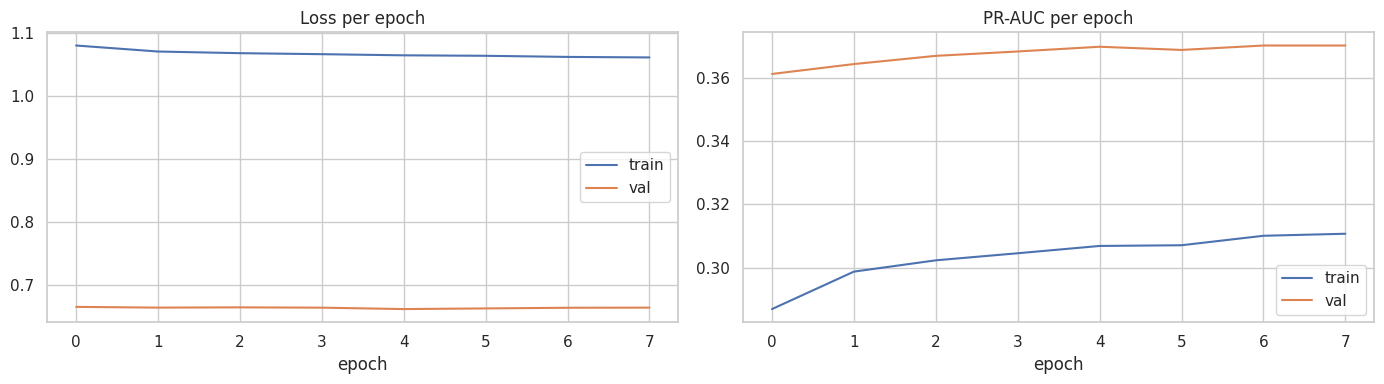

In [24]:
# ---- Evaluate + export aligned probabilities for fusion ------------------------------
p2   = model2.predict(X_seq[te_idx], verbose=0).ravel()
y2   = y_seq[te_idx]

auc_2  = roc_auc_score(y2, p2)
ap_2   = average_precision_score(y2, p2)
thr_2, f1_2 = best_f1_threshold(y2, p2)
_, lo2, hi2 = bootstrap_ci(y2, p2, "auc")

print("Model 2 (Sequential / LSTM on aircraft chains):")
print(f"  ROC-AUC = {auc_2:.3f}   (95% CI {lo2:.3f}-{hi2:.3f})")
print(f"  PR-AUC  = {ap_2:.3f}    (no-skill baseline = {y2.mean():.3f})")
print(f"  F1      = {f1_2:.3f}    at tuned threshold {thr_2:.2f}")

# Per-flight probabilities indexed by flight id -> lets Section 8 fuse the three models.
p2_test_aligned = pd.Series(p2, index=tgt_ids[te_idx]).groupby(level=0).mean()
SEQ_SCORES = {"model": "2. Sequential (LSTM)", "F1": f1_2, "ROC_AUC": auc_2, "PR_AUC": ap_2}

# Training curves — evidence the model trained rather than diverged.
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ax[0].plot(hist.history["loss"], label="train"); ax[0].plot(hist.history["val_loss"], label="val")
ax[0].set_title("Loss per epoch"); ax[0].set_xlabel("epoch"); ax[0].legend()
ax[1].plot(hist.history["pr_auc"], label="train"); ax[1].plot(hist.history["val_pr_auc"], label="val")
ax[1].set_title("PR-AUC per epoch"); ax[1].set_xlabel("epoch"); ax[1].legend()
plt.tight_layout(); plt.show()


## SECTION 7 — Model 3: Graph (airport embeddings)

Section 3.3 showed the airport network is strongly hub-and-spoke. Model 1 only sees that
structure through four hand-made summaries (PageRank and degree). This model learns a **dense
embedding of every airport** from the route network itself, so that airports which sit in similar
positions in the network end up with similar vectors.

**Method.** Build a weighted adjacency matrix `A` from the **training** routes only — `A[i, j]` is
the number of flights flown from airport `i` to airport `j`. Factorise it with truncated SVD to get
a 16-dimensional embedding per airport. Each flight is then represented by its origin embedding
concatenated with its destination embedding (32 values), plus a few pre-departure fields so it is a
fair delay model rather than a pure geography lookup.

Why SVD rather than node2vec: node2vec pins `numpy<2` and breaks pandas in Colab. SVD on the
adjacency matrix is a standard, dependency-free spectral embedding and is fully reproducible.
A trainable GNN (GraphSAGE) is the natural upgrade — see Section 10.

In [25]:
from scipy.sparse import coo_matrix
from sklearn.decomposition import TruncatedSVD

# ---- Adjacency from TRAIN routes only (weighted by flights flown) --------------------
airports = pd.Index(sorted(set(train_df["ORIGIN"]) | set(train_df["DEST"])))
aidx     = {a: i for i, a in enumerate(airports)}
n_air    = len(airports)

r = train_df["ORIGIN"].map(aidx)
c = train_df["DEST"].map(aidx)
ok = r.notna() & c.notna()
A = coo_matrix((np.ones(int(ok.sum()), dtype="float32"),
                (r[ok].astype(int).to_numpy(), c[ok].astype(int).to_numpy())),
               shape=(n_air, n_air)).tocsr()

print(f"Adjacency: {n_air} airports x {n_air}, {A.nnz:,} directed routes, "
      f"{A.sum():,.0f} flights total")

# ---- Spectral embedding --------------------------------------------------------------
EMB_DIM = 16
svd = TruncatedSVD(n_components=EMB_DIM, random_state=RANDOM_STATE)
E   = svd.fit_transform(np.log1p(A))          # log1p tames the huge hub counts
print(f"Embeddings: {E.shape}   explained variance = {svd.explained_variance_ratio_.sum():.1%}")

def embed(frame):
    """Origin embedding || destination embedding; unseen airports -> zeros."""
    oi = frame["ORIGIN"].map(aidx).to_numpy()
    di = frame["DEST"].map(aidx).to_numpy()
    Eo = np.zeros((len(frame), EMB_DIM), dtype="float32")
    Ed = np.zeros((len(frame), EMB_DIM), dtype="float32")
    mo, md_ = ~pd.isna(oi), ~pd.isna(di)
    Eo[mo] = E[oi[mo].astype(int)]
    Ed[md_] = E[di[md_].astype(int)]
    return np.hstack([Eo, Ed])

Etr, Ete = embed(train_df), embed(test_df)
print(f"Flight-level graph features: {Etr.shape[1]} dims per flight")


Adjacency: 307 airports x 307, 4,288 directed routes, 240,000 flights total
Embeddings: (307, 16)   explained variance = 83.5%
Flight-level graph features: 32 dims per flight


In [26]:
# ---- Classifier on the graph embeddings ---------------------------------------------
extra = ["CRS_DEP_HOUR", "O_WSPD", "O_PRCP", "D_WSPD", "D_PRCP"]
Xtr3 = np.hstack([Etr, train_df[extra].fillna(0).to_numpy("float32")])
Xte3 = np.hstack([Ete,  test_df[extra].fillna(0).to_numpy("float32")])

model3 = XGBClassifier(n_estimators=400, max_depth=5, learning_rate=0.05,
                       subsample=0.8, colsample_bytree=0.8, scale_pos_weight=spw,
                       eval_metric="logloss", n_jobs=-1, random_state=RANDOM_STATE)
model3.fit(Xtr3, train_df["DELAYED_15"])
p3 = model3.predict_proba(Xte3)[:, 1]

auc_3 = roc_auc_score(test_df["DELAYED_15"], p3)
ap_3  = average_precision_score(test_df["DELAYED_15"], p3)
thr_3, f1_3 = best_f1_threshold(test_df["DELAYED_15"], p3)
_, lo3, hi3 = bootstrap_ci(test_df["DELAYED_15"], p3, "auc")

print("Model 3 (Graph / SVD airport embeddings):")
print(f"  ROC-AUC = {auc_3:.3f}   (95% CI {lo3:.3f}-{hi3:.3f})")
print(f"  PR-AUC  = {ap_3:.3f}    (no-skill baseline = {test_df['DELAYED_15'].mean():.3f})")
print(f"  F1      = {f1_3:.3f}    at tuned threshold {thr_3:.2f}")

GRAPH_SCORES = {"model": "3. Graph (SVD emb)", "F1": f1_3, "ROC_AUC": auc_3, "PR_AUC": ap_3}

# Which airports does the embedding think are alike? A quick sanity check.
from sklearn.metrics.pairwise import cosine_similarity
hub = "ATL" if "ATL" in aidx else airports[0]
sim = cosine_similarity(E[aidx[hub]].reshape(1, -1), E)[0]
near = pd.Series(sim, index=airports).drop(hub).sort_values(ascending=False).head(6)
print(f"\nAirports most similar to {hub} in embedding space:")
print(near.round(3).to_string())


Model 3 (Graph / SVD airport embeddings):
  ROC-AUC = 0.671   (95% CI 0.665-0.676)
  PR-AUC  = 0.289    (no-skill baseline = 0.167)
  F1      = 0.359    at tuned threshold 0.53

Airports most similar to ATL in embedding space:
ORD    0.847
DTW    0.805
IAH    0.786
EWR    0.785
CLT    0.735
DFW    0.731


## SECTION 8 — Multi-structural fusion & ablation (the payoff)

This is where the research question gets answered. Each model sees a different **structure** of the
same flights. The multi-structural claim is that *combining* structures beats any one of them — so
here we **test** that claim rather than assert it.

Two things make the test honest:

1. **Alignment.** All three models are put onto the *same* test flights. The LSTM only covers legs
   with a prior leg that day, so we report its coverage and evaluate every model on the common subset.
2. **Ablation with confidence intervals.** Starting from tabular alone, we add the graph and the
   sequential signal one at a time, combine them with a simple logistic-regression stacker scored by
   5-fold cross-validation, and attach 95% bootstrap confidence intervals.

> The three base models were trained on the training split and never saw a test label. Only the small
> combiner is cross-fitted on the base models' test predictions, so its score stays unbiased.
> **If two combinations' confidence intervals overlap we do not claim one is better.** Saying that
> plainly is itself a defensible result.

In [27]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_predict, StratifiedKFold

# ---- 1. Put every model's probability on the same index (flight id) ------------------
tab_p   = pd.Series(proba, index=test_df.index, name="tab")     # Model 1 — tabular
graph_p = pd.Series(p3,    index=test_df.index, name="graph")   # Model 3 — graph
seq_p   = p2_test_aligned.reindex(test_df.index).rename("seq")  # Model 2 — sequential

fuse = pd.concat([tab_p, graph_p, seq_p,
                  test_df["DELAYED_15"].rename("y")], axis=1)

coverage = fuse["seq"].notna().mean()
print(f"LSTM covers {coverage:.1%} of test flights "
      f"(first leg of each carrier-day has no history).")

fuse = fuse.dropna()                        # evaluate all models on the common set
yv   = fuse["y"].to_numpy()
print(f"Common evaluation set: {len(fuse):,} flights  |  positive rate {yv.mean():.3f}\n")

# ---- 2. Ablation: does each added structure actually help? ---------------------------
cv = StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE)

def stacked(cols):
    X = fuse[cols].to_numpy()
    p = cross_val_predict(LogisticRegression(max_iter=1000), X, yv,
                          cv=cv, method="predict_proba")[:, 1]
    _, lo, hi = bootstrap_ci(yv, p, "auc")
    return {"ROC_AUC": roc_auc_score(yv, p), "AUC_95%CI": f"{lo:.3f}-{hi:.3f}",
            "PR_AUC": average_precision_score(yv, p)}, p

rows, probs = [], {}
for name, cols in [
    ("Tabular only",                 ["tab"]),
    ("Graph only",                   ["graph"]),
    ("Sequential only",              ["seq"]),
    ("Tabular + Graph",              ["tab", "graph"]),
    ("Tabular + Sequential",         ["tab", "seq"]),
    ("Tabular + Graph + Sequential", ["tab", "graph", "seq"]),
]:
    sc, p = stacked(cols)
    sc["combination"] = name
    rows.append(sc); probs[name] = p

# naive average of all three, for contrast with the learned stacker
naive = fuse[["tab", "graph", "seq"]].mean(axis=1).to_numpy()
rows.append({"combination": "All three (naive average)",
             "ROC_AUC": roc_auc_score(yv, naive), "AUC_95%CI": "-",
             "PR_AUC": average_precision_score(yv, naive)})

ablation = (pd.DataFrame(rows).set_index("combination")
              [["ROC_AUC", "AUC_95%CI", "PR_AUC"]].round(3))
print(ablation.to_string())

# ---- 3. Is the tri-modal gain real, or inside the noise? -----------------------------
best_single = max(ablation.loc[["Tabular only", "Graph only", "Sequential only"], "ROC_AUC"])
tri         = ablation.loc["Tabular + Graph + Sequential", "ROC_AUC"]
tri_lo, tri_hi = ablation.loc["Tabular + Graph + Sequential", "AUC_95%CI"].split("-")
verdict = ("REAL — the tri-modal CI excludes the best single structure"
           if float(tri_lo) > best_single else
           "NOT PROVEN — the intervals overlap; report this honestly")
print(f"\nBest single structure ROC-AUC : {best_single:.3f}")
print(f"Tri-modal stacker    ROC-AUC : {tri:.3f}  (95% CI {tri_lo}-{tri_hi})")
print(f"Verdict: {verdict}")


LSTM covers 99.2% of test flights (first leg of each carrier-day has no history).
Common evaluation set: 59,502 flights  |  positive rate 0.168

                              ROC_AUC    AUC_95%CI  PR_AUC
combination                                               
Tabular only                    0.702  0.697-0.708   0.340
Graph only                      0.670  0.664-0.676   0.290
Sequential only                 0.676  0.670-0.682   0.313
Tabular + Graph                 0.703  0.697-0.709   0.339
Tabular + Sequential            0.712  0.706-0.718   0.353
Tabular + Graph + Sequential    0.712  0.706-0.718   0.353
All three (naive average)       0.708            -   0.346

Best single structure ROC-AUC : 0.702
Tri-modal stacker    ROC-AUC : 0.712  (95% CI 0.706-0.718)
Verdict: REAL — the tri-modal CI excludes the best single structure


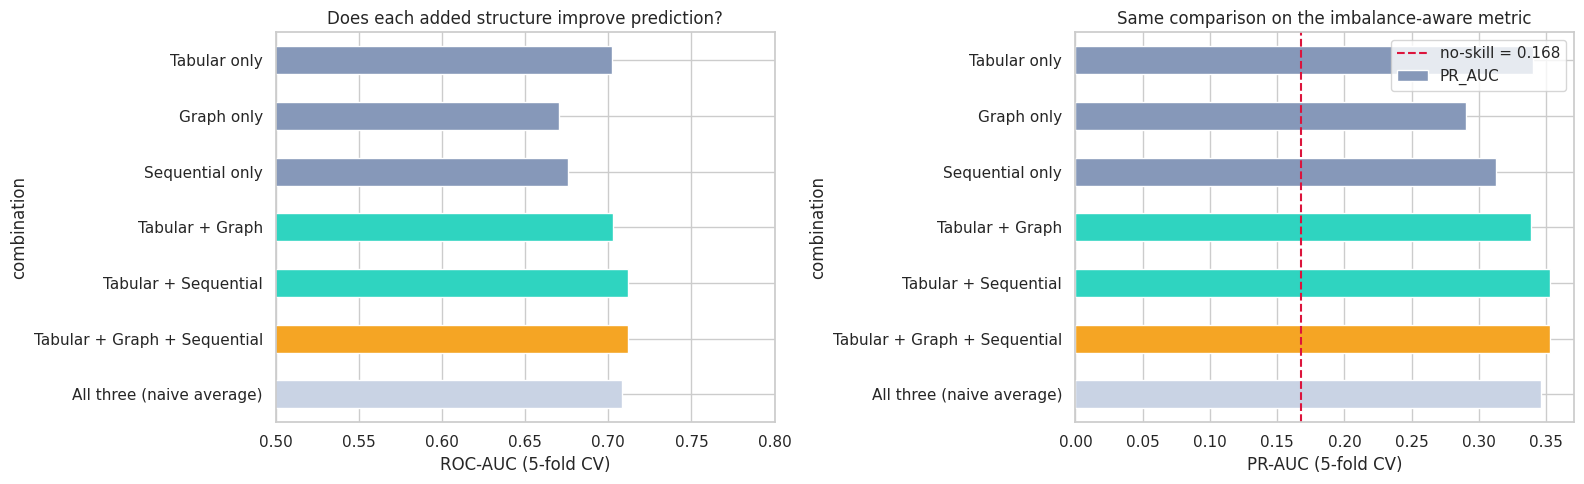

Single-structure model summary (each on its own test set):
                         F1  ROC_AUC  PR_AUC
model                                       
1. Tabular (XGBoost)  0.387    0.703   0.339
2. Sequential (LSTM)  0.360    0.676   0.313
3. Graph (SVD emb)    0.359    0.671   0.289


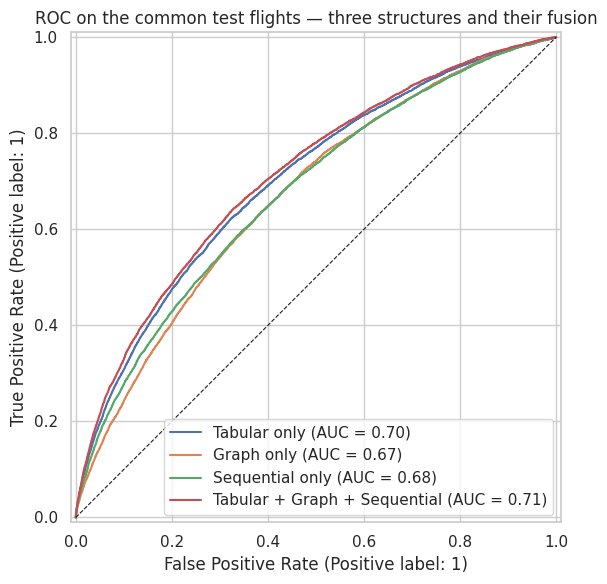

In [28]:
# ---- Visualise the ablation ---------------------------------------------------------
fig, ax = plt.subplots(1, 2, figsize=(16, 5))

colors = ["#8698B9"]*3 + ["#2FD4C0", "#2FD4C0", "#F5A524", "#C9D3E4"]
ablation["ROC_AUC"].plot(kind="barh", ax=ax[0], color=colors[:len(ablation)])
ax[0].set_xlabel("ROC-AUC (5-fold CV)"); ax[0].set_title("Does each added structure improve prediction?")
ax[0].set_xlim(0.5, max(0.80, ablation["ROC_AUC"].max() + 0.03)); ax[0].invert_yaxis()

ablation["PR_AUC"].plot(kind="barh", ax=ax[1], color=colors[:len(ablation)])
ax[1].axvline(yv.mean(), color="crimson", ls="--", label=f"no-skill = {yv.mean():.3f}")
ax[1].set_xlabel("PR-AUC (5-fold CV)"); ax[1].set_title("Same comparison on the imbalance-aware metric")
ax[1].legend(); ax[1].invert_yaxis()
plt.tight_layout(); plt.show()

# ---- Single-structure summary + ROC overlay -----------------------------------------
results = pd.DataFrame([TAB_SCORES, SEQ_SCORES, GRAPH_SCORES]).set_index("model").round(3)
print("Single-structure model summary (each on its own test set):")
print(results.to_string())

fig, ax = plt.subplots(figsize=(7, 6))
for name in ["Tabular only", "Graph only", "Sequential only", "Tabular + Graph + Sequential"]:
    RocCurveDisplay.from_predictions(yv, probs[name], name=name, ax=ax)
ax.plot([0, 1], [0, 1], "k--", lw=0.8)
ax.set_title("ROC on the common test flights — three structures and their fusion")
plt.tight_layout(); plt.show()
